**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 05 - Vectores y matrices: operaciones para transformar datos**

## Complemento

Este notebook se complementa con la presentación: **Algebra_Lineal.pdf**

Te recomendamos leer el PDF para trabajar con este notebook y tener una mejor comprensión de los conceptos teóricos.

¿Qué vamos a poder hacer?

🔍 Detectar y filtrar información relevante, como productos con bajo stock, categorías más frecuentes o proveedores más importantes.

🧮 Realizar operaciones con matrices en Python y entender cómo aplicarlas en contextos reales.

🧩 Construir e interpretar el modelo insumo-producto de Leontief, entendiendo cómo interactúan los sectores productivos de una economía.

🏗️ Diseñar y resolver problemas organizacionales simples a partir de data estructurada.

## Objetivos de la clase

- Entender por qué NumPy existe y cuándo conviene sobre una lista de Python
- Operar con vectores y matrices **sin escribir un solo bucle** (vectorización)
- Leer una tabla como matriz: `shape`, filas, columnas y el famoso `axis`
- Distinguir el producto **elemento a elemento** del **producto matricial**
- Reconocer qué modela cada estructura especial (diagonal, triangular, simétrica)

In [1]:
!pip install numpy matplotlib pandas

In [2]:
#importamos las librerías que vamos a usar en esta ocasión
import numpy as np
import pandas as pd



---
## ⚡ Vectorización: la razón de ser de NumPy

Supongamos que hay que aplicarle el IVA a una lista de precios. Hay tres formas de hacerlo, y las
tres dan el mismo resultado:

| Cómo | Código |
|---|---|
| Con un **bucle** | `for p in precios: nuevos.append(round(p * 1.21, 2))` |
| Con una **comprensión** | `[round(p * 1.21, 2) for p in precios]` |
| Con **NumPy** | `np.round(precios * 1.21, 2)` |

La tercera no solo es más corta: es **mucho más rápida**, porque la multiplicación ocurre de una vez
sobre todo el bloque de memoria en lugar de elemento por elemento.

Eso se llama **vectorización**, y es la idea central de toda la materia: *decile qué querés hacer
con todos los datos, no cómo recorrerlos*.

In [56]:
precios_lista = [12400, 19900, 7450, 4800, 14500, 9900]   # una lista común de Python
precios = np.array(precios_lista)                          # el mismo dato, como array de NumPy

print("Lista de Python :", precios_lista)
print("Array de NumPy  :", precios)

# La diferencia aparece al operar:
print("\nLista * 2  →", precios_lista * 2)      # ⚠️ REPITE la lista, no multiplica
print("Array * 2  →", precios * 2)                # ✅ multiplica cada elemento

Lista de Python : [12400, 19900, 7450, 4800, 14500, 9900]
Array de NumPy  : [12400 19900  7450  4800 14500  9900]

Lista * 2  → [12400, 19900, 7450, 4800, 14500, 9900, 12400, 19900, 7450, 4800, 14500, 9900]
Array * 2  → [24800 39800 14900  9600 29000 19800]


> ⚠️ **Ojo con esa diferencia.** `lista * 2` **duplica la lista** (la pega dos veces);
> `array * 2` multiplica cada valor por dos. No da error: **da otra cosa.** Es una de las confusiones
> más frecuentes al empezar.

In [4]:
unidades = np.array([420, 145, 610, 480, 190, 130])

# Operar entre dos arrays: se aplica posición por posición
facturacion = unidades * precios

print("Unidades   :", unidades)
print("Precios    :", precios)
print("Facturación:", facturacion)
print("\nTotal facturado: $", facturacion.sum())

Unidades   : [420 145 610 480 190 130]
Precios    : [12400 19900  7450  4800 14500  9900]
Facturación: [5208000 2885500 4544500 2304000 2755000 1287000]

Total facturado: $ 18984000


### `dtype`: un array es homogéneo

A diferencia de una lista, **todos los elementos de un array tienen que ser del mismo tipo**.
NumPy elige el tipo que sirva para todos, y ahí hay una trampa:

In [5]:
enteros = np.array([420, 145, 610])
print("Solo enteros      :", enteros.dtype)

mezcla_decimal = np.array([420, 145.5, 610])
print("Con un decimal    :", mezcla_decimal.dtype, "  ← todo pasó a float")

mezcla_texto = np.array([12400, 19900, "sin dato"])
print("Con un texto      :", mezcla_texto.dtype, " ← ⚠️ TODO se volvió texto")
print("Los números ahora son:", mezcla_texto)

Solo enteros      : int64
Con un decimal    : float64   ← todo pasó a float
Con un texto      : <U21  ← ⚠️ TODO se volvió texto
Los números ahora son: ['12400' '19900' 'sin dato']


**Eso último rompe todo lo que venga después.** Si en una columna de precios se coló un
`"sin dato"`, `"N/D"` o un guion, el array entero pasa a ser texto y cualquier cuenta falla.

> 🎯 Es exactamente el mismo problema que veíamos con `dtype: object` en pandas. **El origen suele
> ser un solo dato mal cargado entre miles.**

---
## 🧭 `axis`: la pregunta que confunde a todo el mundo

Cuando una matriz representa una tabla, sumar tiene **dos significados distintos** y hay que elegir:

```
                 Neuquén  Bariloche  Trelew        axis=1 →  suma la FILA
   A101 Harina     420       240      180    →  840          (total del producto)
   B310 Gaseosa    610       380      250    → 1240
                    ↓         ↓        ↓
   axis=0 ↓       1030       620      430          axis=0 →  suma la COLUMNA
                                                             (total de la sucursal)
```

**La regla para no equivocarse:** `axis` indica **qué eje desaparece**.

| Código | Qué eje colapsa | Qué queda | Pregunta que responde |
|---|---|---|---|
| `matriz.sum(axis=0)` | Las filas | Un valor **por columna** | ¿Cuánto vendió cada sucursal? |
| `matriz.sum(axis=1)` | Las columnas | Un valor **por fila** | ¿Cuánto se vendió de cada producto? |
| `matriz.sum()` | Los dos | Un solo número | ¿Cuál es el total general? |

In [6]:
# Filas = productos, columnas = sucursales
ventas = np.array([[420, 240, 180],     # A101 Harina
                   [610, 380, 250],     # B310 Gaseosa
                   [190,   0,  95]])    # L150 Detergente

productos_nom = ["A101 Harina", "B310 Gaseosa", "L150 Detergente"]
sucursales = ["Neuquén", "Bariloche", "Trelew"]

print("shape:", ventas.shape, " → (filas, columnas) = (productos, sucursales)")
print()
print("Total por SUCURSAL (axis=0):", ventas.sum(axis=0))
print("Total por PRODUCTO (axis=1):", ventas.sum(axis=1))
print("Total general             :", ventas.sum())

shape: (3, 3)  → (filas, columnas) = (productos, sucursales)

Total por SUCURSAL (axis=0): [1220  620  525]
Total por PRODUCTO (axis=1): [ 840 1240  285]
Total general             : 2365


In [7]:
# Lo mismo, presentado como se lo mandarías al gerente
import pandas as pd

tablero = pd.DataFrame(ventas, index=productos_nom, columns=sucursales)
tablero["TOTAL producto"] = ventas.sum(axis=1)
tablero.loc["TOTAL sucursal"] = list(ventas.sum(axis=0)) + [ventas.sum()]

tablero

,Neuquén,Bariloche,Trelew,TOTAL producto
A101 Harina,420,240,180,840
B310 Gaseosa,610,380,250,1240
L150 Detergente,190,0,95,285
TOTAL sucursal,1220,620,525,2365


---
## ✖️ `*` contra `@`: dos multiplicaciones distintas

Esta distinción **entra en el parcial** y es la fuente de errores más silenciosa de la unidad.

| Operador | Qué hace | Requisito | Resultado |
|---|---|---|---|
| `A * B` | Multiplica **celda por celda** | Misma forma | Una matriz de la misma forma |
| `A @ B` | **Producto matricial** (filas × columnas) | Columnas de A = filas de B | Una matriz nueva |

El peligro: si las formas coinciden, **`*` no da error, da otro número**.

In [8]:
precios_prod = np.array([12400, 7450, 9900])     # un precio por producto

# ¿Cuánto facturó cada sucursal? Hay que multiplicar precios por unidades y sumar por producto.
# Eso es EXACTAMENTE un producto matricial:
facturacion_sucursal = precios_prod @ ventas

print("Facturación por sucursal:", facturacion_sucursal)
for s, f in zip(sucursales, facturacion_sucursal):
    print(f"  {s:12} $ {f:>10,.0f}")

Facturación por sucursal: [11633500  5807000  5035000]
  Neuquén      $ 11,633,500
  Bariloche    $  5,807,000
  Trelew       $  5,035,000


In [9]:
# Verificamos a mano la primera sucursal, para creerle al @
neuquen = 12400*420 + 7450*610 + 9900*190

print("Neuquén calculado a mano :", neuquen)
print("Neuquén con @            :", facturacion_sucursal[0])
print("¿Coinciden?", neuquen == facturacion_sucursal[0])

Neuquén calculado a mano : 11633500
Neuquén con @            : 11633500
¿Coinciden? True


### Transponer: dar vuelta la tabla

`A.T` intercambia filas por columnas. Sirve cuando la matriz está orientada al revés de lo que
necesita la cuenta — algo que pasa **todo el tiempo** al combinar tablas de distintos sistemas.

In [10]:
print("Original (productos × sucursales):", ventas.shape)
print(ventas)
print("\nTranspuesta (sucursales × productos):", ventas.T.shape)
print(ventas.T)

Original (productos × sucursales): (3, 3)
[[420 240 180]
 [610 380 250]
 [190   0  95]]

Transpuesta (sucursales × productos): (3, 3)
[[420 610 190]
 [240 380   0]
 [180 250  95]]


# Matrices

---
## 🧱 Matrices especiales: cada forma modela algo distinto

No son curiosidades matemáticas. **La estructura de una matriz cuenta cómo funciona el problema:**

| Estructura | Qué modela | Ejemplo de gestión |
|---|---|---|
| **Identidad** | Ningún efecto cruzado, escala 1 | Punto de comparación |
| **Diagonal** | Efectos independientes, sin interacción | Una merma distinta por producto |
| **Triangular** | Dependencia **con orden** | Etapas de producción: corte → costura → terminado |
| **Simétrica** | Relación **recíproca** | Distancias entre plantas |
| **Densa** (sin estructura) | Todo afecta a todo | Requerimientos de recursos |

> 🎯 Cuando te dan una matriz, **mirá su forma antes de calcular**. Si es triangular, hay un orden.
> Si es simétrica, la relación va en los dos sentidos. Eso ya te dice algo del negocio.

In [11]:
I = np.eye(3)                              # identidad
mermas = np.diag([1.03, 1.04, 1.06])       # diagonal: una merma por producto
distancias = np.array([[  0, 520, 680],    # simétrica: la distancia va en los dos sentidos
                       [520,   0, 410],
                       [680, 410,   0]])

print("Identidad:\n", I)
print("\nDiagonal de mermas:\n", mermas)
print("\nDistancias entre plantas:\n", distancias)

Identidad:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Diagonal de mermas:
 [[1.03 0.   0.  ]
 [0.   1.04 0.  ]
 [0.   0.   1.06]]

Distancias entre plantas:
 [[  0 520 680]
 [520   0 410]
 [680 410   0]]


In [12]:
#así armamos una matriz

A = np.array([[1, 4],
              [0, 6]]) #notemos que cada fila está encerrada en corchetes
I= np.identity(2)
print(A)
print(I)


[[1 4]
 [0 6]]
[[1. 0.]
 [0. 1.]]


In [13]:
# Vector columna (3x1) — como los del ejemplo
p = np.array([[100], [250], [80]])
print(p.shape)  # (3, 1)

# Vector fila (1x3)
p_fila = np.array([[100, 250, 80]])
print(p_fila.shape)  # (1, 3)

(3, 1)
(1, 3)


In [14]:
#algunas operaciones básicas de numpy con matrices

# Suma de matrices
C = A + A

# Multiplicación de matrices
D = A @ A

# Transpuesta
A_T = A.T

# Inversa (si existe)
A_inv = np.linalg.inv(A)

print("A+A:")
print(C)
print("\n------------------------\n")

print("A x A")
print(D)
print("\n------------------------\n")

print("Transpuesta de A")
print(A_T)


A+A:
[[ 2  8]
 [ 0 12]]

------------------------

A x A
[[ 1 28]
 [ 0 36]]

------------------------

Transpuesta de A
[[1 0]
 [4 6]]


In [15]:
#algunas características de las matrices
#orden - dimensiones de la matriz (filas, columnas)
print(A.shape)
#rango - número de filas/columnas linealmente independientes
rango_A=np.linalg.matrix_rank(A)
print(rango_A)
#traza - suma de elementos de la diagonal principal
print(np.trace(A))

(2, 2)
2
7


In [16]:
R= np.array([[0,1],
             [0,1]])


In [17]:
#calculemos determinantes
det_R=np.linalg.det(R)
det_A=np.linalg.det(A)
print(det_R)
print(det_A)


0.0
6.0


In [18]:
C=np.array([[3, 4, 5],
            [6, 7, 8],
            [3, 9, 1]])
det_c=np.linalg.det(C)
print(det_c)

41.999999999999986


### 🔍 Verificar una propiedad, no suponerla

Antes de confiar en que una matriz "es simétrica" o "es diagonal", **comprobalo**:

| Propiedad | Qué significa | Cómo se verifica |
|---|---|---|
| Identidad | $A \cdot I = A$ | `np.allclose(A @ I, A)` |
| Simétrica | $M = M^T$ | `np.allclose(M, M.T)` |
| Diagonal | Todo lo de afuera es cero | `np.allclose(A, np.diag(np.diag(A)))` |

> ⚠️ **Nunca compares matrices con `==`.** Eso devuelve una matriz de `True`/`False`, no una
> respuesta. Y con decimales falla por errores de redondeo. Usá siempre **`np.allclose`**.

In [19]:
def describir(nombre, M):
    """Verifica las propiedades de una matriz y devuelve una conclusión, no una matriz."""
    print(f"{nombre}:")
    print("   ¿simétrica? ", np.allclose(M, M.T))
    print("   ¿diagonal?  ", np.allclose(M, np.diag(np.diag(M))))

describir("Distancias", distancias)
describir("Mermas", mermas)
describir("Ventas", ventas)

# Por qué no usar == :
print("\nventas == ventas.T devuelve esto (una matriz, no una respuesta):")
print(ventas == ventas.T)

Distancias:
   ¿simétrica?  True
   ¿diagonal?   False
Mermas:
   ¿simétrica?  True
   ¿diagonal?   True
Ventas:
   ¿simétrica?  False
   ¿diagonal?   False

ventas == ventas.T devuelve esto (una matriz, no una respuesta):
[[ True False False]
 [False  True False]
 [False False  True]]


Definimos una función que nos diga si dos matrices son multiplicables

In [57]:
def son_multiplicables(matriz1, matriz2):

    "Recibe dos matrices (listas de listas) y devuelve True si se pueden multiplicar"


    # Para multiplicar dos matrices, el número de columnas de la primera debe ser igual al número de filas de la segunda.
    columnasm1 = len(matriz1[0])
    filasm2 = len(matriz2)

    return columnasm1 == filasm2


In [58]:
#la probamos con un par de matrices
son_multiplicables(A,R)

True

# DataFrame con Pandas

💪 Pandas nos permite ver todo más bonito y también tiene funciones que facilitan el análisis descriptivo de los datos. Vamos a importar una base de datos sencilla para usar un poco esa librería

En términos generales, muchos conceptos que conocemos de **Numpy** se repiten. Ejemplos de esto incluyen el **indexado** y el **corte (slicing)**, pero también la forma en que se llaman funciones sobre los datos almacenados en un DataFrame.

Para dar un solo ejemplo, si probamos el siguiente código en el DataFrame de abajo:

```python
df["Ventas mensuales"].mean()
```

Es bastante obvio lo que hace este código. Más importante aún, el ejemplo muestra las **similitudes sintácticas** entre Pandas y Numpy. En concreto, primero indexamos una columna usando su nombre y luego llamamos a una función usando el **punto** sobre los datos resultantes, es decir, todas las ventas almacenadas en el DataFrame.

In [60]:
# Los datos se leen por URL del repositorio: funciona igual en Colab y en local
URL = "https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/"
df = pd.read_csv(URL + "productos_stock.csv")
df.head()

,Producto,Categoría,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock,Proveedor
0,A001,Tecnología,150,450.0,30,60,Delta
1,A002,Tecnología,85,120.0,25,45,Delta
2,B101,Hogar,300,80.0,100,20,HogarTop
3,B102,Hogar,120,60.0,70,25,HogarTop
4,C301,Oficina,200,35.0,60,40,OfficePro


In [23]:
# Los datos se leen por URL del repositorio: funciona igual en Colab y en local
URL = "https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/"
df = pd.read_csv(URL + "productos_stock.csv")
df.head()

,Producto,Categoría,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock,Proveedor
0,A001,Tecnología,150,450.0,30,60,Delta
1,A002,Tecnología,85,120.0,25,45,Delta
2,B101,Hogar,300,80.0,100,20,HogarTop
3,B102,Hogar,120,60.0,70,25,HogarTop
4,C301,Oficina,200,35.0,60,40,OfficePro


Por qué usar paths relativos (../) en lugar de absolutos:

  1. Portabilidad - El notebook funciona en cualquier máquina sin cambiar nada
  2. Colaboración - Si compartes el código con otros, no necesitan tener la misma estructura
  de carpetas en C:\Users\pepito\...
  3. Git - Los paths relativos se versionar mejor; los absolutos causan conflictos

In [61]:
df.info() #muestra la estructura del dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Producto             10 non-null     object 
 1   Categoría            10 non-null     object 
 2   Stock actual         10 non-null     int64  
 3   Precio unitario (€)  10 non-null     float64
 4   Ventas mensuales     10 non-null     int64  
 5   Días en stock        10 non-null     int64  
 6   Proveedor            10 non-null     object 
dtypes: float64(1), int64(3), object(3)
memory usage: 692.0+ bytes


In [62]:
df.describe() #resumen estadístico

,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock
count,10.000000,10.000000,10.000000,10.000000
mean,340.500000,83.750000,160.000000,29.500000
std,301.481988,133.806919,189.428966,17.765447
min,85.000000,3.000000,25.000000,10.000000
25%,157.500000,16.250000,48.750000,15.750000
50%,210.000000,42.500000,85.000000,22.500000
75%,375.000000,75.000000,142.500000,43.750000
max,1000.000000,450.000000,600.000000,60.000000


In [63]:
df["Categoría"].value_counts() #cuenta cuántos productos hay por categoría

,count
Categoría,
Tecnología,2
Hogar,2
Oficina,2
Limpieza,2
Alimentos,2


In [27]:
df.groupby("Categoría").mean(numeric_only=True) #promedios por categoría

,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock
Categoría,,,,
Alimentos,875.0,3.75,500.0,11.0
Hogar,210.0,70.00,85.0,22.5
Limpieza,310.0,17.50,135.0,16.5
Oficina,190.0,42.50,52.5,45.0
Tecnología,117.5,285.00,27.5,52.5


In [64]:
df.groupby("Proveedor")["Stock actual"].sum() #stock por proveedor

,Stock actual
Proveedor,
Delta,235
HogarTop,420
LimpioYA,620
OfficePro,380
SanoPlus,1750


In [65]:
df[df["Stock actual"] < 100]  #productos con bajo stock

,Producto,Categoría,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock,Proveedor
1,A002,Tecnología,85,120.0,25,45,Delta


In [66]:
# Ejemplos de .iloc (por POSICION/NUMERO) y .loc (por ETIQUETA/NOMBRE)

# CASO 1: .iloc - selecciona por NUMERO de posición
primeros_3_productos = df.iloc[0:3]  # primeras 3 filas (posiciones 0, 1, 2)
print('Primeros 3 productos (iloc):')
print(primeros_3_productos)

# CASO 2: .loc - selecciona por ETIQUETA/NOMBRE (índice)
fila_especifica = df.loc[0]  # fila con índice 0
print('Fila con índice 0 (loc):')
print(fila_especifica)

# CASO 3: .iloc - selecciona columna por número
segunda_columna = df.iloc[:, 1]  # todas las filas, segunda columna (posición 1)
print('Segunda columna (iloc):')
print(segunda_columna.head())

# CASO 4: .loc - selecciona columna por nombre
columna_producto = df.loc[:, 'Producto']  # todas las filas, columna 'Producto'
print('Columna Producto (loc):')
print(columna_producto.head())

# CASO 5: Combinar - filtrar con .loc
bajo_stock = df.loc[df['Stock actual'] < 100, ['Producto', 'Stock actual']]  # donde stock < 100
print('Productos con bajo stock (loc con condición):')
print(bajo_stock)

Primeros 3 productos (iloc):
  Producto   Categoría  Stock actual  Precio unitario (€)  Ventas mensuales  \
0     A001  Tecnología           150                450.0                30   
1     A002  Tecnología            85                120.0                25   
2     B101       Hogar           300                 80.0               100   

   Días en stock Proveedor  
0             60     Delta  
1             45     Delta  
2             20  HogarTop  
Fila con índice 0 (loc):
Producto                     A001
Categoría              Tecnología
Stock actual                  150
Precio unitario (€)         450.0
Ventas mensuales               30
Días en stock                  60
Proveedor                   Delta
Name: 0, dtype: object
Segunda columna (iloc):
0    Tecnología
1    Tecnología
2         Hogar
3         Hogar
4       Oficina
Name: Categoría, dtype: object
Columna Producto (loc):
0    A001
1    A002
2    B101
3    B102
4    C301
Name: Producto, dtype: object
Productos con

## Caso 1
⚡

Supongamos que una empresa evalúa a sus empleados en 3 criterios:

*   Productividad
*   Trabajo en equipo
*   Puntualidad

Cada área (Ventas, Logística, Administración) tiene varios empleados, y queremos calcular el promedio de puntajes por área para compararlas de forma objetiva

In [68]:
#vamos a representar los puntajes con matrices
#filas: empleados
#columnas: criterios
import numpy as np
import pandas as pd

ventas = np.array([[8, 9, 10],
                   [7, 8, 9],
                   [9, 9, 10]])

logistica = np.array([[6, 7, 8],
                      [7, 6, 7],
                      [6, 8, 7]])

administracion = np.array([[9, 8, 3],
                           [8, 7, 3],
                           [7, 8, 4]])

criterios = ['Productividad', 'Trabajo en equipo', 'Puntualidad']


In [69]:
#convertimos a dataframe para que se vea bonito y mas sencillo de manejar
df_ventas = pd.DataFrame(ventas, columns=criterios)
df_logistica = pd.DataFrame(logistica, columns=criterios)
df_admin = pd.DataFrame(administracion, columns=criterios)


In [70]:
#calculamos el promedio por área
prom_ventas = df_ventas.mean()
prom_logistica = df_logistica.mean()
prom_admin = df_admin.mean()

print("Promedios en Ventas:")
print(prom_ventas)
print("\nPromedios en Logística:")
print(prom_logistica)
print("\nPromedios en Administración:")
print(prom_admin)


Promedios en Ventas:
Productividad        8.000000
Trabajo en equipo    8.666667
Puntualidad          9.666667
dtype: float64

Promedios en Logística:
Productividad        6.333333
Trabajo en equipo    7.000000
Puntualidad          7.333333
dtype: float64

Promedios en Administración:
Productividad        8.000000
Trabajo en equipo    7.666667
Puntualidad          3.333333
dtype: float64


## Caso 2
⚡

Una empresa quiere implementar un protocolo para revisar con prioridad las maquinarias que:

* Superan las 3000 horas de uso, y

* Tienen un costo de mantenimiento mayor a 4000 U$D

Tu tarea es ayudar al equipo de gestión a identificar estas maquinarias.

In [71]:

data = {
    "Nombre": ["Autoelevador A1", "Montacargas X3","Grúa G5", "Carretilla eléctrica R2"],
    "Horas de uso al mes": [400, 100, 89, 250],
    "Mantenimiento (U$/año)": [3500, 2800, 2000, 5000],
    "Estado": ["En servicio", "En servicio", "En servicio", "En servicio"]
}

df_maquinarias = pd.DataFrame(data)
df_maquinarias


,Nombre,Horas de uso al mes,Mantenimiento (U$/año),Estado
0,Autoelevador A1,400,3500,En servicio
1,Montacargas X3,100,2800,En servicio
2,Grúa G5,89,2000,En servicio
3,Carretilla eléctrica R2,250,5000,En servicio


In [72]:
#creamos la columna de rendimiento, es un ratio una relacion entre cantidades
df_maquinarias["Rendimiento"] = df_maquinarias["Horas de uso al mes"] / df_maquinarias["Mantenimiento (U$/año)"]

In [73]:
#clasificamos el rendimiento
condiciones = [
    (df_maquinarias["Rendimiento"] > 0.1),
    (df_maquinarias["Rendimiento"] > 0.05) & (df_maquinarias["Rendimiento"] <= 0.1),
    (df_maquinarias["Rendimiento"] <= 0.05)
]
clasificaciones = ["Alto", "Medio", "Bajo"]
df_maquinarias["Clasificación"] = np.select(condiciones, clasificaciones,default="Sin datos")

In [75]:
#filtramos las de bajo rendimiento
bajo_rendimiento = df_maquinarias[df_maquinarias["Clasificación"] == "Bajo"]
bajo_rendimiento


,Nombre,Horas de uso al mes,Mantenimiento (U$/año),Estado,Rendimiento,Clasificación
1,Montacargas X3,100,2800,En servicio,0.035714,Bajo
2,Grúa G5,89,2000,En servicio,0.044500,Bajo
3,Carretilla eléctrica R2,250,5000,En servicio,0.050000,Bajo


✋ Resolvamos algunos problemas utilizando vectores

---



aca entra la organizacion FUTBOL

In [76]:
import numpy as np
import pandas as pd

datos = np.array([
    [10, 28, 15, 8],
    [7, 31, 12, 14],
    [9, 25, 18, 5],
    [11, 30, 9, 11],
    [8, 27, 7, 9],
    [5, 29, 3, 6]
])
#DT= RITA
jugadores = ["Manuel", "Tadeo", "Juan", "Santiago", "Lucas", "Joaquín"]

tabla = pd.DataFrame(
    datos,
    index=jugadores,
    columns=["Dorsal", "Partidos", "Goles", "Asistencias"]
)

print(tabla)

          Dorsal  Partidos  Goles  Asistencias
Manuel        10        28     15            8
Tadeo          7        31     12           14
Juan           9        25     18            5
Santiago      11        30      9           11
Lucas          8        27      7            9
Joaquín        5        29      3            6


In [77]:
#Goles a favor del equipo
goles_a_favor_del_equipo = np.sum(datos[:, 2])
print(f"goles a favor del equipo = {goles_a_favor_del_equipo}")


goles a favor del equipo = 64


In [78]:
#Máximo artillero
posicion = np.argmax(datos[:, 2])
print(jugadores[posicion])

Juan


In [98]:
#Participación
participacion = datos[:, 2] + datos[:, 3]
#"Tabla = tabla.T" para trasponer la tabla y luego ejecutar comando print (Tabla); esto es para trasponer y trabajar como filas. Deben ser mismas filas y columnas
tabla["Participación ofensiva"] = participacion

print(tabla)

          Dorsal  Partidos  Goles  Asistencias  Participación ofensiva
Manuel        10        28     15            8                      23
Tadeo          7        31     12           14                      26
Juan           9        25     18            5                      23
Santiago      11        30      9           11                      20
Lucas          8        27      7            9                      16
Joaquín        5        29      3            6                       9


---
# ⚽ Caso aplicado: la Liga Profesional 2018

Hasta acá practicamos con tablas inventadas. Ahora vamos con **datos reales**: la tabla de
posiciones de la **Liga Profesional Argentina 2018**.

La idea es la de siempre, pero con un dataset que no armamos nosotros:

| | |
|---|---|
| **Una fila** | Un equipo |
| **Una columna** | Una estadística (puntos, goles, partidos ganados...) |

> 🎯 **Por qué 2018 y no un año más reciente:** 2020 fue el año de la pandemia. El torneo se
> suspendió, se jugó sin público y el calendario quedó partido al medio. Los datos existen, pero
> **no describen una temporada normal**. Elegir el período es la primera decisión de cualquier
> análisis, y casi nunca es inocente.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL_FUTBOL = ("https://raw.githubusercontent.com/LucasSequeDev/"
              "scrapper-dataset-futbol-argentino-python/master/"
              "dataset_posiciones_Liga_Profesional_Argentina_2018.csv")

posiciones = pd.read_csv(URL_FUTBOL)

print("Forma de la tabla:", posiciones.shape, " → (equipos, columnas)")
print("\nColumnas disponibles:")
print(list(posiciones.columns))

posiciones.head()

Forma de la tabla: (28, 17)  → (equipos, columnas)

Columnas disponibles:
['Unnamed: 0', 'equipo', 'puntos', 'golesFavor', 'golesEnContra', 'partidos', 'ganados', 'empatados', 'perdidos', 'diferenciaGoles', 'ganadosLocal', 'ganadosVisitante', 'empatadosLocal', 'empatadosVisitante', 'perdidosLocal', 'perdidosVisitante', 'torneo']


,Unnamed: 0,equipo,puntos,golesFavor,golesEnContra,partidos,ganados,empatados,perdidos,diferenciaGoles,ganadosLocal,ganadosVisitante,empatadosLocal,empatadosVisitante,perdidosLocal,perdidosVisitante,torneo
0,0,Boca Juniors,58,50,22,27,14,4,9,28,12,6,0,4,2,3,Liga Profesional Argentina 2018
1,1,Olimpo,15,16,50,27,9,6,12,-34,2,1,4,2,7,11,Liga Profesional Argentina 2018
2,2,Temperley,23,22,46,27,10,8,9,-24,2,3,4,4,8,6,Liga Profesional Argentina 2018
3,3,River Plate,45,39,26,27,9,6,12,13,7,6,4,2,2,6,Liga Profesional Argentina 2018
4,4,Tigre,24,26,33,27,8,12,7,-7,3,1,6,6,5,6,Liga Profesional Argentina 2018


## De la tabla a la matriz

Pandas nos sirvió para **traer** los datos. Ahora los pasamos a **NumPy** para operarlos, que es
justo el puente que venimos trabajando en toda la clase.

Separamos en dos estructuras:

- **`equipos`**: un vector de textos con los nombres.
- **`M`**: la **matriz** numérica (equipos × estadísticas).

In [81]:
columnas = ['partidos', 'ganados', 'empatados', 'perdidos',
            'golesFavor', 'golesEnContra', 'diferenciaGoles', 'puntos']

equipos = posiciones['equipo'].to_numpy()              # vector de nombres
M = posiciones[columnas].to_numpy(dtype=int)           # matriz equipos × estadísticas

# Un diccionario para no tener que acordarnos en qué posición está cada columna
col = {nombre: i for i, nombre in enumerate(columnas)}

print(f"M es una matriz de {M.shape[0]} equipos × {M.shape[1]} estadísticas")
print("\nÍndice de columnas:")
for nombre, i in col.items():
    print(f"   {i} → {nombre}")

M es una matriz de 28 equipos × 8 estadísticas

Índice de columnas:
   0 → partidos
   1 → ganados
   2 → empatados
   3 → perdidos
   4 → golesFavor
   5 → golesEnContra
   6 → diferenciaGoles
   7 → puntos


> 💡 **Ese diccionario `col` es un truco que conviene copiar.** Escribir `M[:, col['puntos']]` se
> entiende; escribir `M[:, 7]` no. Es la misma idea de las claves con nombre que vimos en la clase 00.

## 🔍 Antes de calcular nada: ¿los datos cierran?

Es la misma pregunta que nos hicimos con las matrices simétricas: **verificar, no suponer.**

Con una tabla de posiciones tenemos la ventaja de que hay **reglas que se tienen que cumplir sí o sí**:

1. Ganados + empatados + perdidos = partidos jugados
2. Puntos = 3 × ganados + 1 × empatados

Si alguna no se cumple, el dataset tiene un problema. Comprobémoslo con operaciones vectorizadas.

In [82]:
# Control 1: ¿la suma de resultados da los partidos jugados?
suma_resultados = M[:, col['ganados']] + M[:, col['empatados']] + M[:, col['perdidos']]
control_1 = suma_resultados == M[:, col['partidos']]

# Control 2: ¿los puntos se corresponden con los resultados?
puntos_calculados = 3 * M[:, col['ganados']] + M[:, col['empatados']]
control_2 = puntos_calculados == M[:, col['puntos']]

print(f"Control 1 — G+E+P = PJ        : {control_1.sum()} de {len(M)} equipos")
print(f"Control 2 — puntos = 3G + E   : {control_2.sum()} de {len(M)} equipos   ⚠️")

print("\nAlgunos casos donde el control 2 falla:")
for i in np.where(~control_2)[0][:4]:
    print(f"   {equipos[i]:16} dice {M[i, col['puntos']]:2} puntos, "
          f"pero 3×{M[i, col['ganados']]}+{M[i, col['empatados']]} = {puntos_calculados[i]}")

Control 1 — G+E+P = PJ        : 28 de 28 equipos
Control 2 — puntos = 3G + E   : 2 de 28 equipos   ⚠️

Algunos casos donde el control 2 falla:
   Boca Juniors     dice 58 puntos, pero 3×14+4 = 46
   Olimpo           dice 15 puntos, pero 3×9+6 = 33
   Temperley        dice 23 puntos, pero 3×10+8 = 38
   River Plate      dice 45 puntos, pero 3×9+6 = 33


### 😬 Encontramos un problema

Los puntos **no se corresponden** con los partidos ganados y empatados. Y no es un caso aislado:
falla en casi todos los equipos.

Antes de descartar el dataset, miremos las otras columnas: la tabla también trae el desglose de
resultados **como local y como visitante**. Si esas sí cierran, el problema está solo en las columnas
resumidas.

In [83]:
# Reconstruimos los resultados sumando local + visitante
ganados_real   = posiciones['ganadosLocal']   + posiciones['ganadosVisitante']
empatados_real = posiciones['empatadosLocal'] + posiciones['empatadosVisitante']
perdidos_real  = posiciones['perdidosLocal']  + posiciones['perdidosVisitante']

puntos_desglose = 3 * ganados_real + empatados_real
control_3 = (puntos_desglose == posiciones['puntos']).sum()
control_4 = ((ganados_real + empatados_real + perdidos_real) == posiciones['partidos']).sum()

print(f"Con el DESGLOSE local + visitante:")
print(f"   puntos = 3G + E      : {control_3} de {len(posiciones)} equipos  ✅")
print(f"   G + E + P = PJ       : {control_4} de {len(posiciones)} equipos  ✅")

print("\nComparación para cuatro equipos:")
print(f"{'equipo':16}{'columna G':>11}{'desglose G':>12}{'puntos':>9}")
for eq in ['Boca Juniors', 'River Plate', 'Independiente', 'Olimpo']:
    f = posiciones['equipo'] == eq
    print(f"{eq:16}{posiciones.loc[f,'ganados'].iloc[0]:>11}"
          f"{ganados_real[f].iloc[0]:>12}{posiciones.loc[f,'puntos'].iloc[0]:>9}")

Con el DESGLOSE local + visitante:
   puntos = 3G + E      : 28 de 28 equipos  ✅
   G + E + P = PJ       : 28 de 28 equipos  ✅

Comparación para cuatro equipos:
equipo            columna G  desglose G   puntos
Boca Juniors             14          18       58
River Plate               9          13       45
Independiente            11          13       46
Olimpo                    9           3       15


> 🚨 **Conclusión: la columna `ganados` del dataset está mal.** Los valores correctos son los que
> salen de sumar local + visitante, y con esos los puntos cierran en **los 28 equipos**.
>
> **Esto no es un detalle de la clase: es la clase.** Si hubiéramos ido derecho a calcular sin
> controlar, habríamos informado que Olimpo ganó 9 partidos cuando en realidad ganó 3. El código
> habría funcionado perfecto y el resultado habría estado mal.

**Corregimos la matriz y seguimos.**

In [84]:
# Pisamos las tres columnas con los valores reconstruidos
M[:, col['ganados']]   = ganados_real.to_numpy()
M[:, col['empatados']] = empatados_real.to_numpy()
M[:, col['perdidos']]  = perdidos_real.to_numpy()

# Y volvemos a controlar: ahora tiene que dar 28 de 28
ok = (3 * M[:, col['ganados']] + M[:, col['empatados']] == M[:, col['puntos']])
print(f"Después de corregir: {ok.sum()} de {len(M)} equipos consistentes ✅")

Después de corregir: 28 de 28 equipos consistentes ✅


## Ejercicio 1 — Diferencia de gol

La diferencia de gol es una **resta de dos columnas**. Con NumPy se hace de una vez para los 28
equipos, sin recorrer nada.

In [85]:
goles_favor  = M[:, col['golesFavor']]
goles_contra = M[:, col['golesEnContra']]

diferencia = goles_favor - goles_contra          # resta vectorizada: 28 cuentas en una línea

# El dataset ya trae esa columna: la usamos para verificar
coincide = np.array_equal(diferencia, M[:, col['diferenciaGoles']])
print("¿Coincide con la columna del dataset?", coincide)

# Los cinco mejores y los cinco peores
orden = np.argsort(diferencia)[::-1]
print("\nMejor diferencia de gol:")
for i in orden[:5]:
    print(f"   {equipos[i]:18} {diferencia[i]:+3}   ({goles_favor[i]} a favor, {goles_contra[i]} en contra)")
print("\nPeor diferencia de gol:")
for i in orden[-3:]:
    print(f"   {equipos[i]:18} {diferencia[i]:+3}")

¿Coincide con la columna del dataset? True

Mejor diferencia de gol:
   Boca Juniors       +28   (50 a favor, 22 en contra)
   Godoy Cruz         +21   (45 a favor, 24 en contra)
   Racing Club        +14   (46 a favor, 32 en contra)
   Talleres Córdoba   +13   (33 a favor, 20 en contra)
   River Plate        +13   (39 a favor, 26 en contra)

Peor diferencia de gol:
   Chacarita Juniors  -17
   Temperley          -24
   Olimpo             -34


## Ejercicio 2 — Buscar un equipo con una máscara booleana

Para quedarnos con la fila de un equipo usamos una **máscara**: un vector de `True`/`False` del
mismo largo que la tabla, que le dice a NumPy qué filas conservar.

In [86]:
def buscar_equipo(texto):
    """Devuelve los resultados de un equipo. La búsqueda es parcial y no distingue mayúsculas."""
    mascara = np.array([texto.lower() in nombre.lower() for nombre in equipos])

    if mascara.sum() == 0:
        print(f"No hay ningún equipo que contenga '{texto}'")
        return

    fila = M[mascara][0]
    print(f"{equipos[mascara][0]:16} → "
          f"ganados: {fila[col['ganados']]:2} | empatados: {fila[col['empatados']]:2} | "
          f"perdidos: {fila[col['perdidos']]:2} | puntos: {fila[col['puntos']]:2}")

buscar_equipo('independiente')
buscar_equipo('river')

Independiente    → ganados: 13 | empatados:  7 | perdidos:  7 | puntos: 46
River Plate      → ganados: 13 | empatados:  6 | perdidos:  8 | puntos: 45


## Ejercicio 3 — ¿El que más ganó es el que más puntos tiene?

`np.argmax` devuelve **la posición** del valor más alto de un vector. Con eso ubicamos la fila del
equipo que encabeza cada estadística.

In [88]:
i_mas_ganados = np.argmax(M[:, col['ganados']])
i_mas_puntos  = np.argmax(M[:, col['puntos']])

print(f"Más partidos ganados: {equipos[i_mas_ganados]:16} ({M[i_mas_ganados, col['ganados']]} triunfos)")
print(f"Más puntos          : {equipos[i_mas_puntos]:16} ({M[i_mas_puntos, col['puntos']]} puntos)")

if i_mas_ganados == i_mas_puntos:
    print(f"\nEs el mismo equipo. Tiene sentido: los partidos ganados son los que más pesan.")
else:
    print(f"\nSon equipos distintos: los empates alcanzan para dar vuelta la tabla.")

Más partidos ganados: Boca Juniors     (18 triunfos)
Más puntos          : Boca Juniors     (58 puntos)

Es el mismo equipo. Tiene sentido: los partidos ganados son los que más pesan.


## Ejercicio 4 — Un gráfico para comparar

Con las máscaras ya sabemos ubicar equipos. Ahora los graficamos.

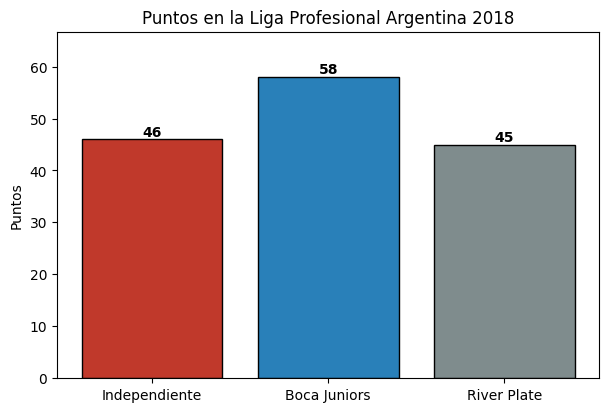

In [89]:
buscados = ['independiente', 'boca', 'river']
nombres, puntos = [], []

for texto in buscados:
    mascara = np.array([texto in nombre.lower() for nombre in equipos])
    nombres.append(equipos[mascara][0])
    puntos.append(M[mascara, col['puntos']][0])

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(nombres, puntos, color=['#C0392B', '#2980B9', '#7F8C8D'], edgecolor='black')

# El número arriba de cada barra: sin esto hay que adivinar el valor
for barra, valor in zip(barras, puntos):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.6, str(valor),
            ha='center', fontweight='bold')

ax.set_title('Puntos en la Liga Profesional Argentina 2018')
ax.set_ylabel('Puntos')
ax.set_ylim(0, max(puntos) * 1.15)
plt.show()

### 🧭 Qué nos llevamos de este caso

| Lo que hicimos | Con qué |
|---|---|
| Trajimos los datos | `pd.read_csv()` |
| Los pasamos a matriz | `.to_numpy()` |
| Operamos columnas enteras | Resta vectorizada, sin ciclos |
| Buscamos filas | Máscaras booleanas |
| Encontramos el máximo | `np.argmax()` |
| **Controlamos que cerraran** | **Reglas que se tienen que cumplir** |

> 🎯 **La más importante es la última.** El dataset venía con una columna mal y el código no se
> hubiera quejado: habría devuelto números prolijos y equivocados. Lo que salvó el análisis no fue
> saber NumPy, fue **preguntarse si los datos cerraban antes de usarlos**.

**Para seguir practicando:**
1. Ordená la tabla completa por puntos con `np.argsort` y mostrá el podio.
2. Calculá el promedio de goles a favor por partido de todos los equipos a la vez.
3. Compará el rendimiento **como local contra como visitante**: ¿qué equipo depende más de su cancha?

---
# 📝 Ejercicios

> 💡 En todos: **antes de correr el código, escribí qué forma esperás que tenga el resultado**
> (cuántas filas, cuántas columnas). Después comprobalo con `.shape`. Es la mejor costumbre que te
> podés llevar de esta clase: la mitad de los errores con matrices son de forma, no de cuentas.

### ✅ Ejercicio 1 — Vectores

Las ventas de una sucursal durante seis meses fueron:

```python
ventas = np.array([420, 445, 470, 505, 530, 545])
```

1. ¿Cuántos elementos tiene? ¿Qué devuelve `ventas.shape` y por qué tiene esa forma rara con la coma?
2. Calculá el total del semestre, el promedio mensual y el mejor mes.
3. Aplicá un aumento del 12% a todos los meses **en una sola línea**, sin usar un ciclo.
4. Calculá la variación mes a mes con `np.diff()`. ¿Cuántos elementos tiene el resultado?
   ¿Por qué **uno menos**?

In [51]:
import numpy as np

ventas = np.array([420, 445, 470, 505, 530, 545])

# Tu código acá

### ✅ Ejercicio 2 — `axis`: la pregunta que confunde a todo el mundo

Una empresa tiene tres sucursales y cuatro meses de ventas:

```python
ventas = np.array([
    [120, 135, 150, 145],   # Centro
    [ 95,  88, 102, 110],   # Norte
    [145, 160, 158, 172],   # Sur
])
```

1. ¿Qué forma tiene la matriz? ¿Qué representa cada dimensión?
2. Calculá el **total por sucursal**. ¿Va `axis=0` o `axis=1`?
3. Calculá el **total por mes**.
4. Calculá el **promedio de cada sucursal** y decí cuál rinde mejor.
5. **La trampa:** ¿qué devuelve `ventas.sum()` sin ningún `axis`? ¿En qué caso te sirve ese número?

In [52]:
ventas = np.array([
    [120, 135, 150, 145],   # Centro
    [ 95,  88, 102, 110],   # Norte
    [145, 160, 158, 172],   # Sur
])

# Tu código acá

### ✅ Ejercicio 3 — `*` contra `@`: el error más caro

Una fábrica produce tres productos. Esta matriz dice **cuántas unidades** de cada insumo lleva cada
producto:

| | Madera | Tornillos | Pintura |
|---|---|---|---|
| **Silla** | 3 | 12 | 1 |
| **Mesa** | 8 | 20 | 2 |
| **Estante** | 5 | 16 | 1 |

Y los insumos cuestan: madera \$ 4.500, tornillos \$ 120, pintura \$ 2.800.

1. Armá la matriz `insumos` (3×3) y el vector `precios` (3 elementos).
2. Calculá el **costo de fabricar una unidad de cada producto**. ¿Va `*` o `@`? Pensalo antes.
3. Probá **las dos** operaciones y mirá qué forma devuelve cada una. ¿Qué está calculando `*`?
4. Si la empresa fabrica 40 sillas, 15 mesas y 25 estantes, ¿cuál es el **costo total**?
5. ¿Cuántas unidades de cada insumo necesita comprar para esa producción?

In [53]:
# Tu código acá

### ✅ Ejercicio 4 — Matrices especiales

1. Creá una **matriz identidad** de 4×4 con `np.eye(4)`.
2. Multiplicá por ella la matriz de ventas del Ejercicio 2 (¡cuidado con las formas!) y verificá que
   no cambia nada. ¿Por qué la identidad es "el 1" de las matrices?
3. Creá una **matriz diagonal** con `np.diag([1.10, 1.05, 1.20])`, que representa un aumento
   distinto para cada sucursal.
4. Aplicásela a las ventas para que **cada sucursal reciba su propio aumento**. Verificá que Centro
   subió 10%, Norte 5% y Sur 20%.
5. **Verificá una propiedad, no la supongas:** comprobá con código que $(A^T)^T = A$.

In [54]:
# Tu código acá

---
### 🎯 Ejercicio integrador — "Metalúrgica del Plata"

Una metalúrgica fabrica **tres productos** en **dos plantas**. La producción mensual es:

| Planta A | Perfiles | Chapas | Tubos |
|---|---|---|---|
| **Producción** | 320 | 180 | 240 |

| Planta B | Perfiles | Chapas | Tubos |
|---|---|---|---|
| **Producción** | 410 | 95 | 300 |

Cada producto requiere estas horas de trabajo y kilos de acero por unidad:

| | Horas | Acero (kg) |
|---|---|---|
| **Perfiles** | 1.5 | 8 |
| **Chapas** | 2.0 | 12 |
| **Tubos** | 1.2 | 6 |

La hora de trabajo cuesta \$ 4.800 y el kilo de acero \$ 950.

**Se pide:**

1. Armá la matriz de producción (2 plantas × 3 productos) y la de requerimientos (3 productos × 2 recursos).
2. Calculá, con **una sola operación matricial**, cuántas horas y cuántos kilos de acero consume
   cada planta. ¿Qué forma tiene el resultado y por qué?
3. Calculá el **costo total de cada planta**.
4. ¿Qué **participación** tiene cada planta en el costo total? (en porcentaje)
5. La empresa quiere **aumentar la producción de la Planta B un 15%** y **reducir la de A un 10%**.
   Armá las nuevas matrices y calculá el nuevo costo total.
6. **La pregunta de gestión:** el gerente dice que "la Planta B es más eficiente porque produce más
   unidades". Con los números en la mano, ¿es un buen argumento? ¿Qué medirías vos para comparar
   dos plantas?

> 📌 Se evalúa que las **formas de las matrices** estén bien pensadas (el punto 2 no sale si están
> al revés) y, sobre todo, **la respuesta al punto 6**.

In [55]:
import numpy as np

# 1) Las matrices
produccion = np.array([
    [320, 180, 240],    # Planta A
    [410,  95, 300],    # Planta B
])

# Tu código acá

---
## 🧭 Para llevarse

| Concepto | Comando |
|---|---|
| Crear un array | `np.array(lista)` |
| Matriz de ceros / unos / identidad | `np.zeros((f,c))` · `np.ones((f,c))` · `np.eye(n)` |
| Forma de la tabla | `A.shape` → `(filas, columnas)` |
| Total por columna / por fila | `A.sum(axis=0)` · `A.sum(axis=1)` |
| Multiplicar celda a celda | `A * B` |
| **Producto matricial** | `A @ B` |
| Transponer | `A.T` |
| Diagonal | `np.diag(v)` |
| Comparar matrices | `np.allclose(A, B)` — **nunca `==`** |

**Las tres ideas de la clase:**
1. **Vectorizar** es decir qué hacer con todos los datos, no cómo recorrerlos.
2. `axis` indica **qué eje desaparece**: `axis=0` colapsa filas, `axis=1` colapsa columnas.
3. `*` y `@` son operaciones **distintas** y ninguna avisa cuando elegiste mal.

En la próxima clase usamos todo esto para resolver sistemas de ecuaciones.